![PIC UPV PERTE Chip Chair Logo](https://www.pic-chair.upv.es/wp-content/uploads/2024/05/logo-upv-horizontal.png)
![PIC UPV PERTE Chip Chair Logo](https://www.pic-chair.upv.es/wp-content/uploads/2024/06/logos-perte-chip-1024x119.png)

# Laboratory 4. Process Design Kit (PDK) and Layout

In [1]:
import gdsfactory as gf

## 1. Technology

We will work with the **demo UPVfab PDK**. (There are some other open-source PDKs, in other technologies, feel free to search if interested)

In [2]:
from upvfab.sin300.cband import PDK, cells

Let's view the layer distribution of this PDK. In our case, for the passive devices we will only use the **Layer 1**. 

2026-06-02 23:56:17.547 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


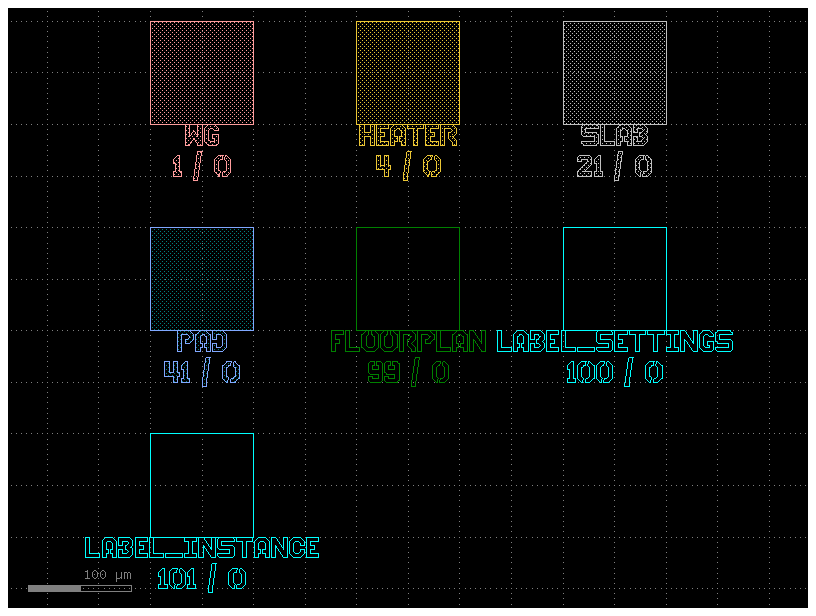

In [3]:
LAYER_VIEWS = PDK.layer_views
c = LAYER_VIEWS.preview_layerset()
c.show()
c.plot()


The new versions of GDS Factory allow to view the Layer Stack also (3D view of the fabrication flow). The following code allows to generate and view the Layer Stack of the generic PDK. Reference: https://www.degruyter.com/document/doi/10.1515/nanoph-2013-0034/html

The layers and the thicknesses have been defined previously on the PDK, so it is possible to view in 3D some of the components in the PDK. 

See the [Reference Manual](https://gdsfactory.github.io/gdsfactory/components.html) and read the list of the available components.

Here are some examples of the 3D views of this photonic components

2026-06-02 23:56:18.320 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


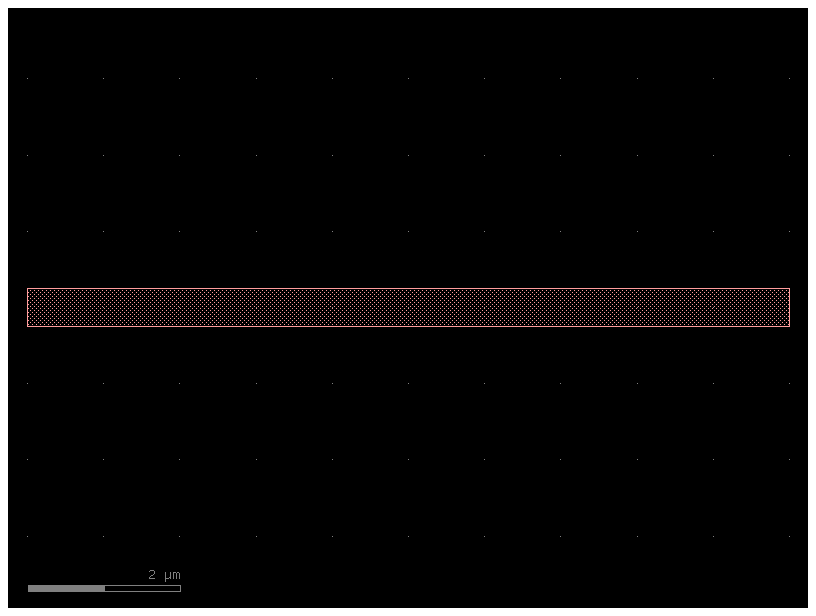

In [4]:
xs = gf.cross_section.strip(width=0.5, layer = 'WG')

c = gf.components.straight(length=10, cross_section=xs)  #Deep 
c.plot() # To view the component on Notebook
c.show() # To view on KLayout
scene = c.to_3d()
scene.show()


2026-06-02 23:56:19.034 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server
2026-06-02 23:56:19.600 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


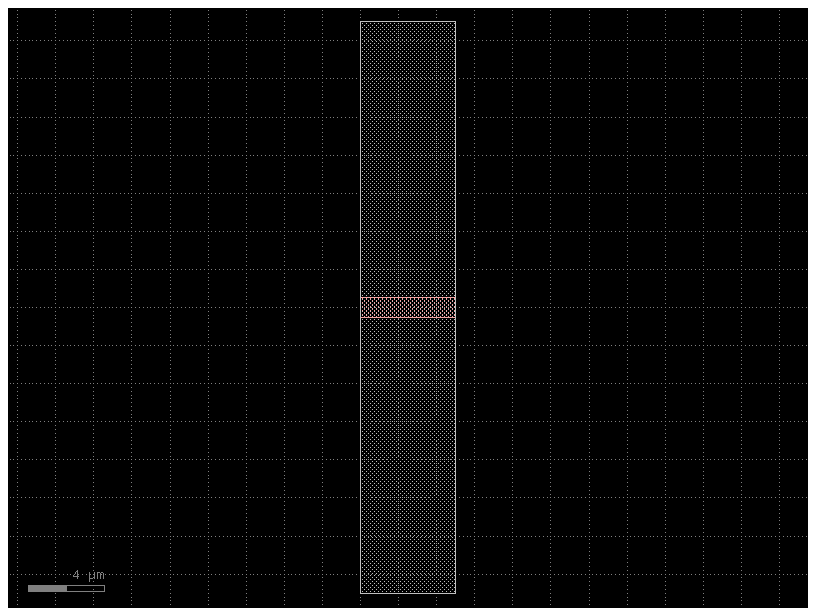

In [5]:
c = gf.components.straight(length=5, cross_section='rib') #Shallow
c.plot()
c.show()

scene = c.to_3d()
c.show()
scene.show()

In [6]:
c = cells.taper_strip_to_ridge(length=10) #Taper
c.show()

scene = c.to_3d()
scene.show()

2026-06-02 23:56:20.296 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


2026-06-02 23:56:20.995 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


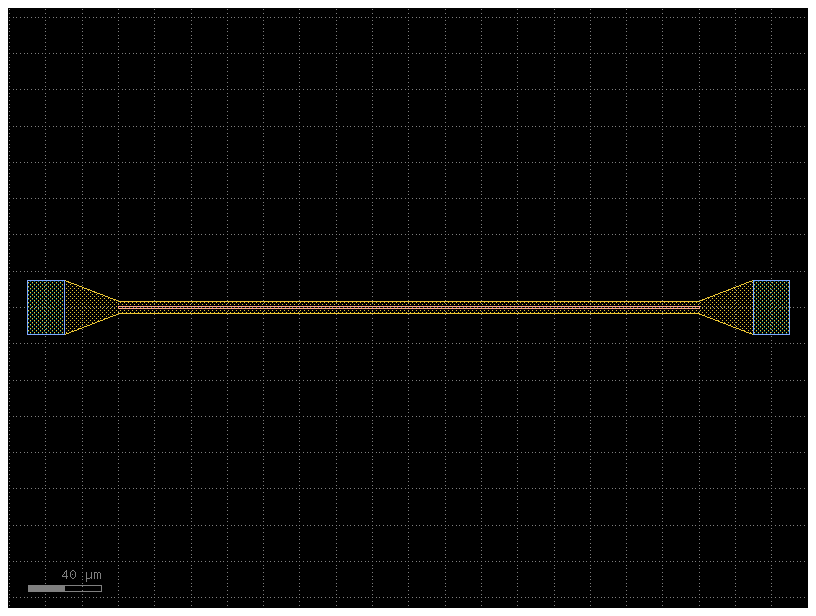

In [7]:
c = cells.straight_heater_metal()

#c.pprint_ports()

c.plot()
c.show()
#c.draw_ports()

scene = c.to_3d()
scene.show()

- Use your design results from Lab2 and Lab3 to create **layout** instances of your designed components: DCs, MMIs, MZIs & Ring Resonators. 

2026-06-02 23:56:21.791 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


┏━━━━━━┳━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┓
┃ name ┃ width ┃ orientation ┃ layer    ┃ center          ┃ port_type ┃
┡━━━━━━╇━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━┩
│ o1   │ 1.0   │ 180.0       │ WG (1/0) │ (-100.0, -24.2) │ optical   │
│ o2   │ 1.0   │ 180.0       │ WG (1/0) │ (-100.0, 25.8)  │ optical   │
│ o3   │ 1.0   │ 0.0         │ WG (1/0) │ (114.5, 25.8)   │ optical   │
│ o4   │ 1.0   │ 0.0         │ WG (1/0) │ (114.5, -24.2)  │ optical   │
└──────┴───────┴─────────────┴──────────┴─────────────────┴───────────┘

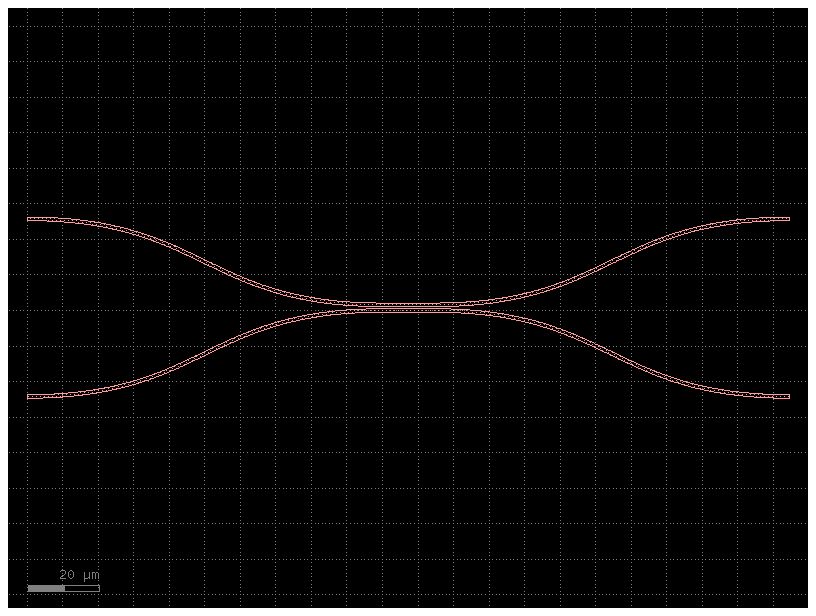

In [8]:
# Directional Coupler  gap=0.6 µm, length=L_pi from Lab2
dc = cells.coupler(gap=0.6, length=14.5)
dc.plot()
dc.show()
cells.coupler().pprint_ports()

┏━━━━━━┳━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━┓
┃ name ┃ width ┃ orientation ┃ layer    ┃ center        ┃ port_type ┃
┡━━━━━━╇━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━┩
│ o1   │ 1.0   │ 180.0       │ WG (1/0) │ (-20.0, -1.0) │ optical   │
│ o2   │ 1.0   │ 180.0       │ WG (1/0) │ (-20.0, 1.0)  │ optical   │
│ o3   │ 1.0   │ 0.0         │ WG (1/0) │ (62.5, 1.0)   │ optical   │
│ o4   │ 1.0   │ 0.0         │ WG (1/0) │ (62.5, -1.0)  │ optical   │
└──────┴───────┴─────────────┴──────────┴───────────────┴───────────┘

2026-06-02 23:56:22.523 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


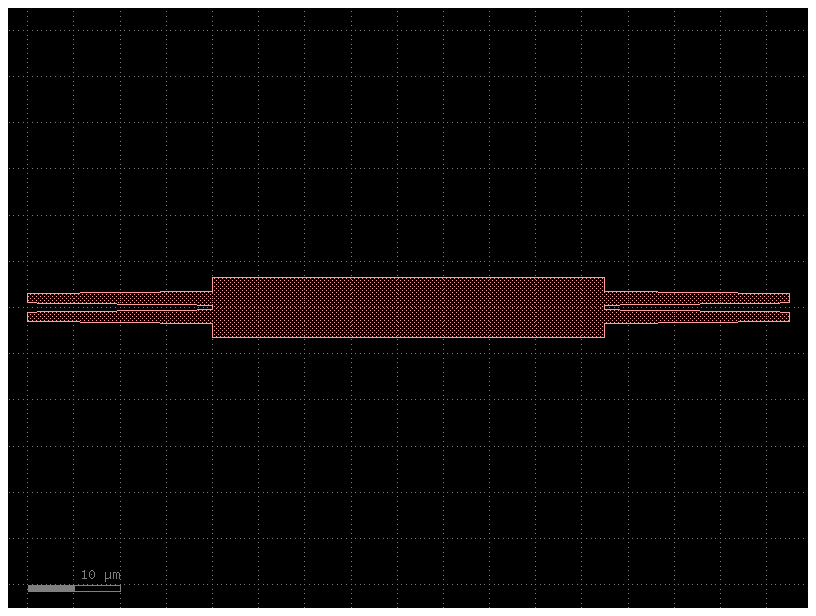

In [9]:

# 2x2 MMI width_mmi=6.6 µm, length_mmi from Lab2
mmi2x2 = cells.mmi2x2(width_mmi=6.6, gap_mmi=0.5, length_mmi=42.5)
cells.mmi2x2().pprint_ports(),
mmi2x2.plot()
mmi2x2.show()


┏━━━━━━┳━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┓
┃ name ┃ width ┃ orientation ┃ layer    ┃ center           ┃ port_type ┃
┡━━━━━━╇━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━┩
│ o1   │ 1.0   │ 180.0       │ WG (1/0) │ (-20.0, 0.0)     │ optical   │
│ o2   │ 1.0   │ 0.0         │ WG (1/0) │ (302.0, 201.57)  │ optical   │
│ o3   │ 1.0   │ 0.0         │ WG (1/0) │ (302.0, 198.43)  │ optical   │
│ o4   │ 1.0   │ 0.0         │ WG (1/0) │ (302.0, -198.43) │ optical   │
│ o5   │ 1.0   │ 0.0         │ WG (1/0) │ (302.0, -201.57) │ optical   │
└──────┴───────┴─────────────┴──────────┴──────────────────┴───────────┘

2026-06-02 23:56:23.251 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


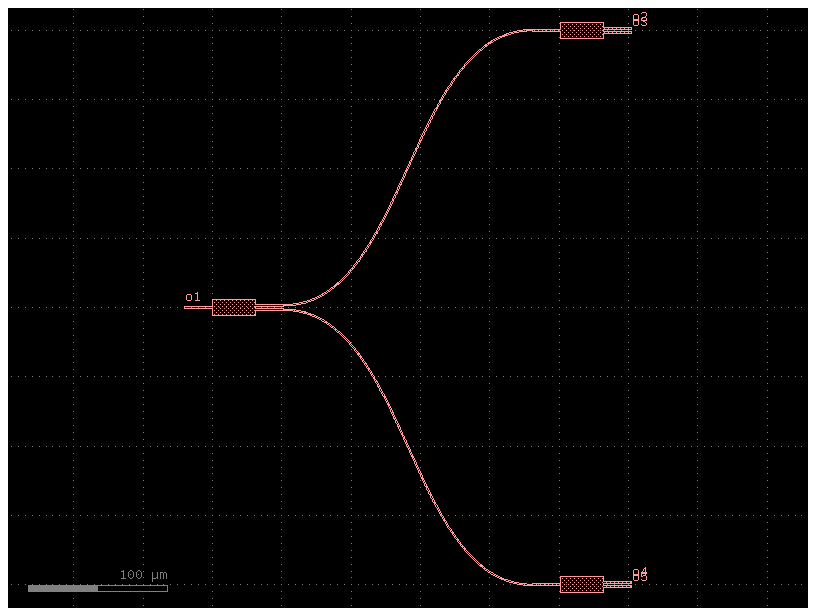

In [10]:
# 1x4 MMI tree — built from two levels of mmi1x2, wMMI=12 µm from Lab2
mmi1x4 = gf.Component()
c_1x2 = cells.mmi1x2(width_mmi=12)
root = mmi1x4.add_ref(c_1x2)
l2_top = mmi1x4.add_ref(c_1x2)
l2_bot = mmi1x4.add_ref(c_1x2)
l2_top.dmovex(root.dxmax + 200).dmovey(200)
l2_bot.dmovex(root.dxmax + 200).dmovey(-200)
gf.routing.route_single_sbend(component=mmi1x4, port1=root['o2'], port2=l2_top['o1'], cross_section='strip')
gf.routing.route_single_sbend(component=mmi1x4, port1=root['o3'], port2=l2_bot['o1'], cross_section='strip')
mmi1x4.add_port(name='o1', port=root['o1'])
mmi1x4.add_port(name='o2', port=l2_top['o2'])
mmi1x4.add_port(name='o3', port=l2_top['o3'])
mmi1x4.add_port(name='o4', port=l2_bot['o2'])
mmi1x4.add_port(name='o5', port=l2_bot['o3'])
mmi1x4.draw_ports()
mmi1x4.pprint_ports()
mmi1x4.plot()
mmi1x4.show()

2026-06-02 23:56:24.004 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


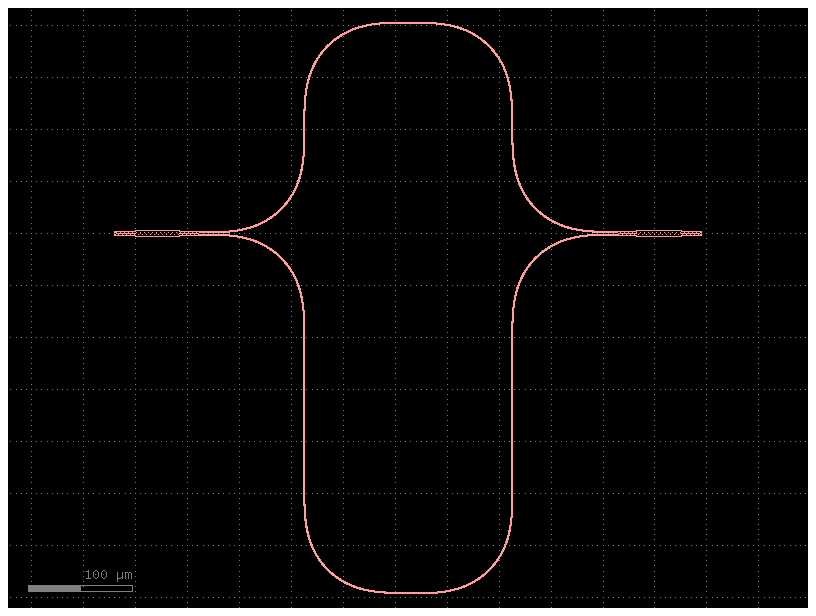

In [11]:
# MZI  delta_length=286 µm from Lab3
mzi = cells.mzi(delta_length=286, splitter='mmi2x2', combiner='mmi2x2')
mzi.plot()
mzi.show()



2026-06-02 23:56:24.736 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


┏━━━━━━┳━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━┓
┃ name ┃ width ┃ orientation ┃ layer    ┃ center        ┃ port_type ┃
┡━━━━━━╇━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━┩
│ o2   │ 1.0   │ 0.0         │ WG (1/0) │ (100.0, 0.0)  │ optical   │
│ o1   │ 1.0   │ 180.0       │ WG (1/0) │ (-104.0, 0.0) │ optical   │
└──────┴───────┴─────────────┴──────────┴───────────────┴───────────┘

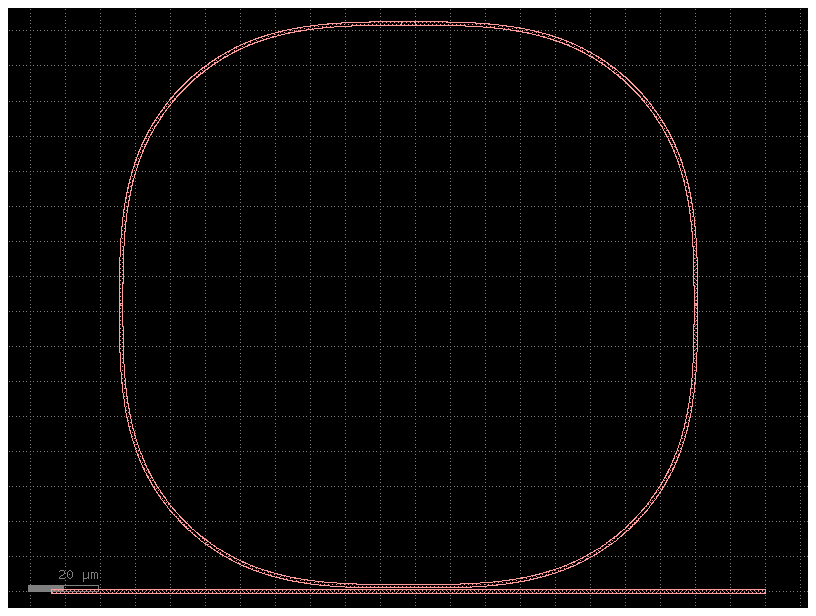

In [12]:
# All-pass ring resonator — gap=0.5 µm, radius=80 µm from Lab3
ring = cells.ring_single(gap=0.5, radius=80)
ring.plot()
ring.show()
cells.ring_single().pprint_ports()

## 2. Layout Fundamentals

A cell is a function that returns a Component. In GDS each component must have a unique name. Two components stored in the GDS file cannot have the same name. They need to be references (instances) of the same component.

![GDSFactoryComponents][def]


[def]: https://i.imgur.com/oeuKGsc.png

2026-06-02 23:56:25.432 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


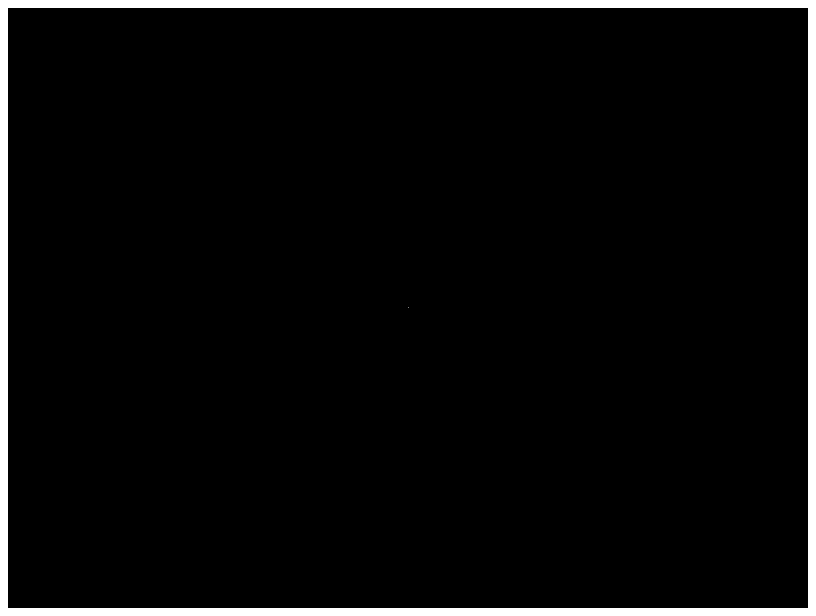

In [13]:
c = gf.Component()
c.plot()
c.show()

Let's build a Component from scratch. A die (chip) for a photonic layout. The PDK or Design Manual should specify the Layer for the bounding box (dicing line). 
We should also consider: 
1. The die dimensions and 
2. The border for dicing 

2026-06-02 23:56:26.096 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


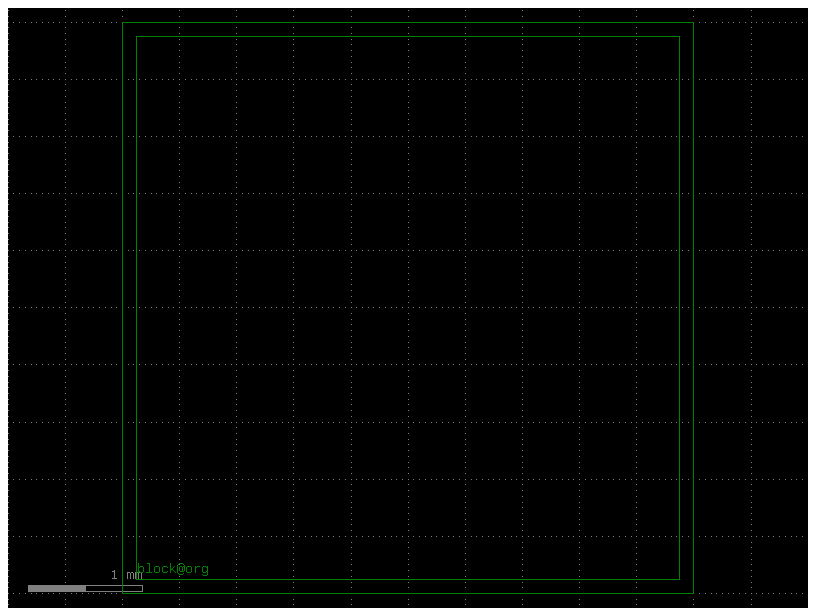

In [14]:
wgw = 0.5
dieL = 5000
dieW = 5000
border = 125
layer_wg = "WG"
layer_box = "FLOORPLAN"

# Die specifications (Chip)
box = gf.Component()

obox = box.add_ref(gf.components.rectangle(size=(dieW,dieL),layer=layer_box))
ibox = box.add_ref(gf.components.rectangle(size=(dieW-border*2,dieL-border*2),layer=layer_box)).dmovex(border).dmovey(border)
box = gf.boolean(A=obox, B=ibox, operation="A-B", layer="FLOORPLAN")

# Adding ports to a component 
box.add_port(name="block@org", center=[border,border], width=1, orientation=0, layer=layer_box)

box.draw_ports()
box.show()
box.plot()

2026-06-03 00:11:19.646 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


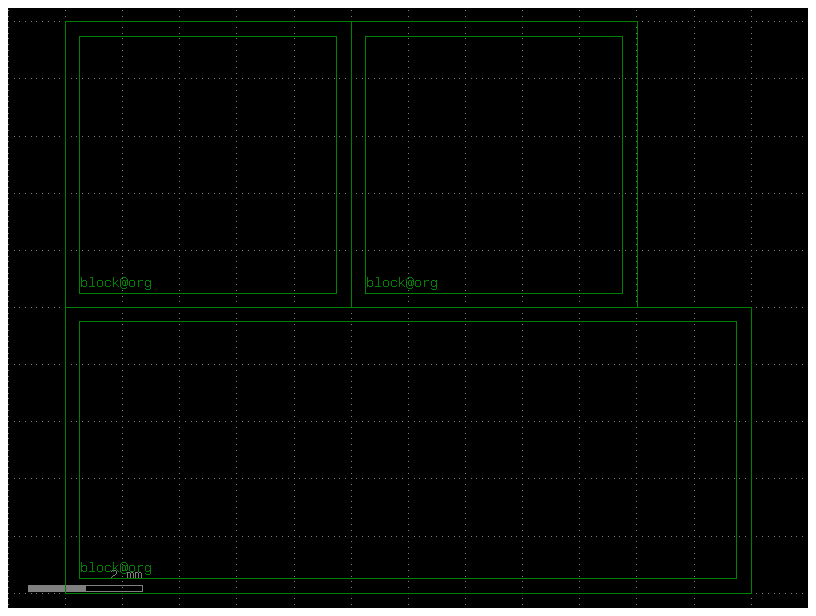

In [39]:
# 1. We define the cell as a function with it's corresponding parameters (and defaults)
gf.clear_cache()

@gf.cell
def die(dieL = 5000, dieW = 5000, border = 250, layer_box = "FLOORPLAN"):
    # Die specifications (Chip)
    box = gf.Component()
    obox = box.add_ref(gf.components.rectangle(size=(dieW,dieL),layer=layer_box))
    ibox = box.add_ref(gf.components.rectangle(size=(dieW-border*2,dieL-border*2),layer=layer_box)).dmovex(border).dmovey(border)
    box = gf.boolean(A=obox, B=ibox, operation="A-B", layer=layer_box)
    # Adding ports to a component 
    box.add_port(name="block@org", center=[border,border], width=1, orientation=0, layer=layer_box)
    box.draw_ports()
    return box

# 2. We instantiate references of each cell. We can also name it individually to avoid problems
wafer = gf.Component()
dieW1 = 5000
dieW2 = 10000

c1 = wafer.add_ref(die(dieW = dieW))
c2 = wafer.add_ref(die(dieW = dieW))
c3 = wafer.add_ref(die(dieW = 12000))

c2.dmovex(dieW1)
c3.dmovey(-5000)
wafer.show()
wafer.plot()

LO2b

2026-06-03 00:15:09.159 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


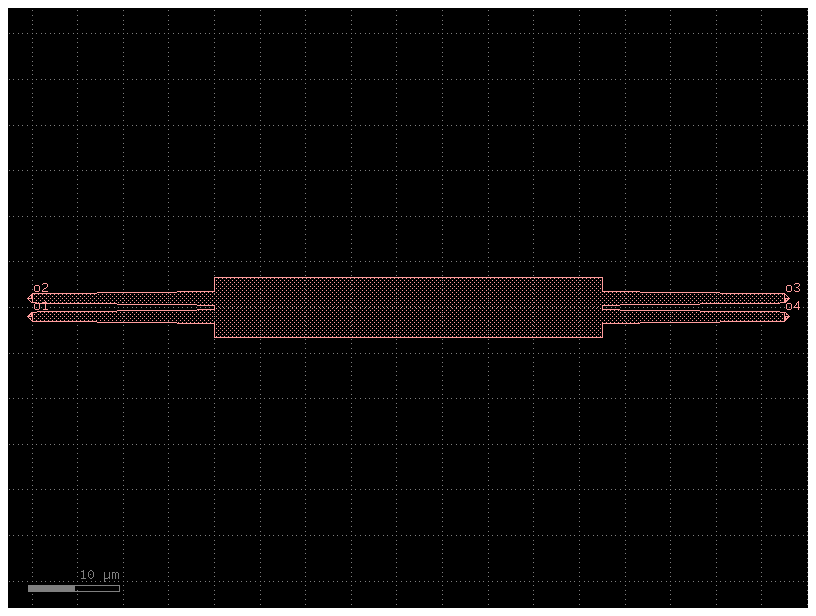

In [44]:
@gf.cell
def mmi2x2_cell(width_mmi=6.6, gap_mmi=0.5, length_mmi=42.5):
    c = gf.Component()
    mmi = c.add_ref(cells.mmi2x2(width_mmi=width_mmi, gap_mmi=gap_mmi, length_mmi=length_mmi))
    c.add_port(name='o1', port=mmi['o1'])
    c.add_port(name='o2', port=mmi['o2'])
    c.add_port(name='o3', port=mmi['o3'])
    c.add_port(name='o4', port=mmi['o4'])
    c.draw_ports()
    return c

mmi2x2_cell().plot()
mmi2x2_cell().show()

┏━━━━━━┳━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┓
┃ name ┃ width ┃ orientation ┃ layer    ┃ center          ┃ port_type ┃
┡━━━━━━╇━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━┩
│ in1  │ 1.0   │ 180.0       │ WG (1/0) │ (-100.0, -24.2) │ optical   │
│ in2  │ 1.0   │ 180.0       │ WG (1/0) │ (-100.0, 25.8)  │ optical   │
│ out1 │ 1.0   │ 0.0         │ WG (1/0) │ (729.1, 25.8)   │ optical   │
│ out2 │ 1.0   │ 0.0         │ WG (1/0) │ (729.1, -24.2)  │ optical   │
└──────┴───────┴─────────────┴──────────┴─────────────────┴───────────┘

2026-06-02 23:56:29.007 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


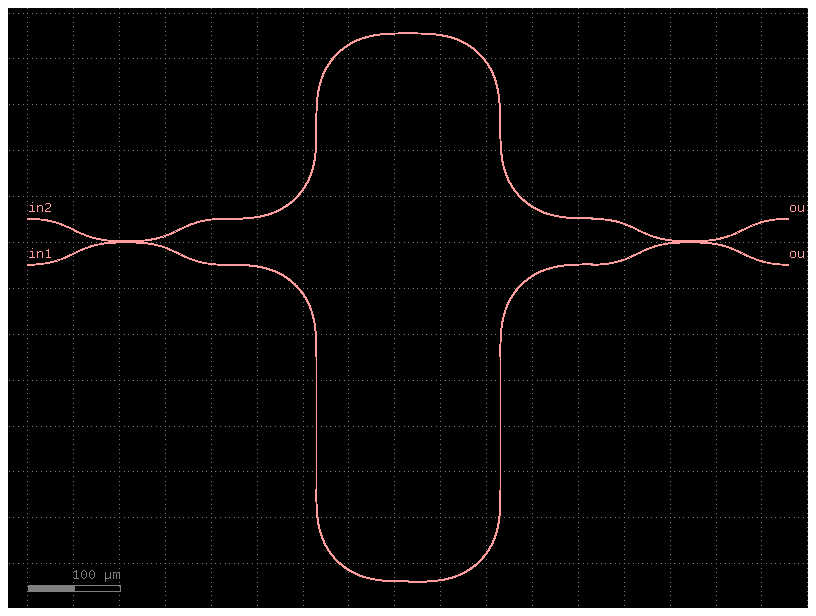

In [18]:


@gf.cell
def mzi_cell(delta_length=286):
    c = gf.Component()
    mzi = c.add_ref(cells.mzi(delta_length=delta_length))
    c.add_port(name='in1', port=mzi['o1'])
    c.add_port(name='in2', port=mzi['o2'])
    c.add_port(name='out1', port=mzi['o3'])
    c.add_port(name='out2', port=mzi['o4'])
    c.draw_ports()
    return c

mzi_cell().pprint_ports()
mzi_cell().plot()
mzi_cell().show()

2026-06-02 23:56:29.708 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


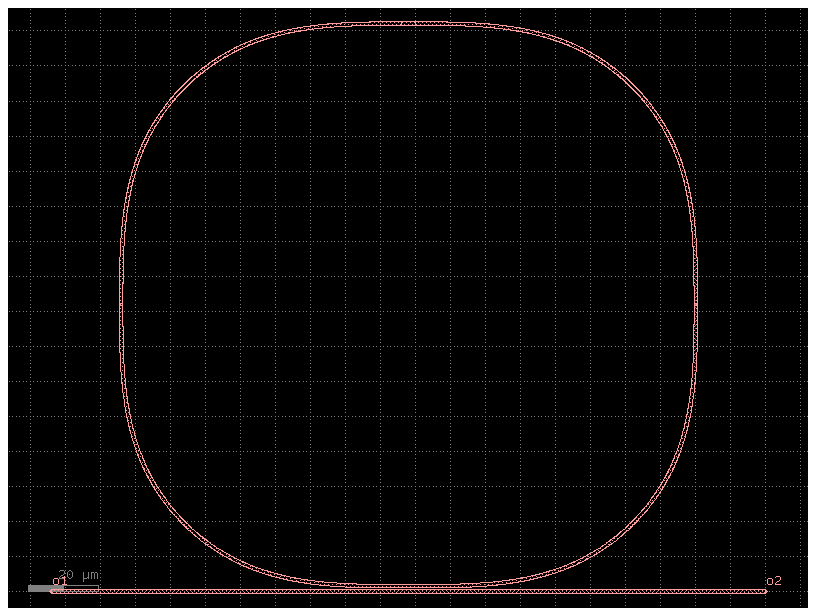

In [19]:
@gf.cell
def ring_cell(gap=0.5, radius=80):
    c = gf.Component()
    ring = c.add_ref(cells.ring_single(gap=gap, radius=radius))
    c.add_port(name='o1', port=ring['o1'])
    c.add_port(name='o2', port=ring['o2'])
    c.draw_ports()
    return c

ring_cell().plot()
ring_cell().show()

## 3.Complete Layout

2026-06-02 23:56:30.415 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


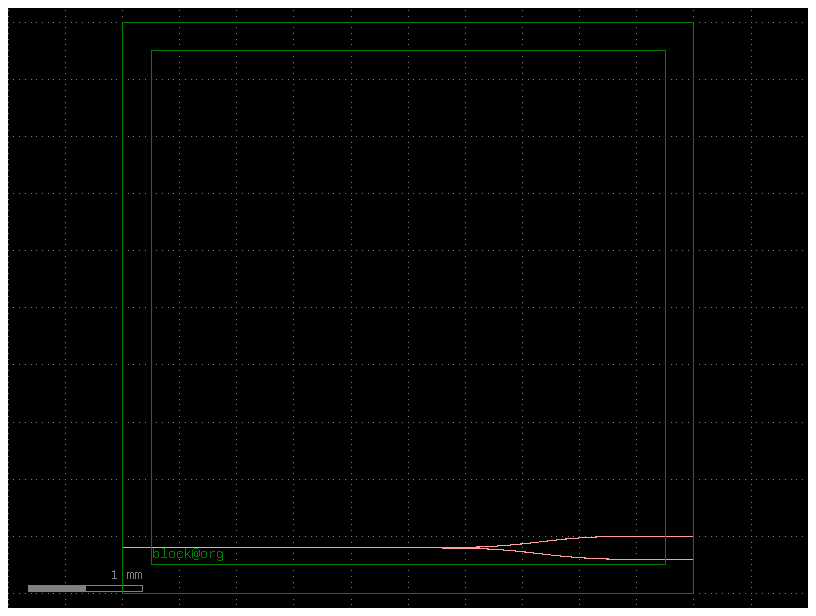

In [20]:
layer_wg  = "WG"
minrad = 50
dieW = 5000

main = gf.Component()

die_ref = main.add_ref(die(dieW = dieW, layer_box="FLOORPLAN"))

## Add first a test MMI routed from side to side
c_mmi = cells.mmi1x2()
mmi = main.add_ref(c_mmi)
mmi.dmovex(die_ref["block@org"].dx + 0.5*dieW).dmovey(die_ref['block@org'].dy + 150)

## Route waveguides from MMI to the die edges
xs = 'strip'
### First add the i/o waveguides - to be sure you 'cut' on a straight section
strin = (main.add_ref(gf.components.straight(length=500, cross_section='strip')).dmovex(0).dmovey(mmi['o1'].dy))
strout1 = (main.add_ref(gf.components.straight(length=500, cross_section=xs)).drotate(180).dmovey(mmi.ports['o3'].dy-100).dmovex(dieW))
strout2 = (main.add_ref(gf.components.straight(length=500, cross_section=xs)).drotate(180).dmovey(mmi.ports['o2'].dy+100).dmovex(dieW))
### Then route from the i/o waveguides to the MMI
gf.routing.route_single_sbend(main,port1=strin['o2'], port2=mmi['o1'], cross_section=xs)
gf.routing.route_single_sbend(main,port1=mmi['o2'], port2=strout2['o2'], cross_section=xs)
gf.routing.route_single_sbend(main,port1=mmi['o3'], port2=strout1['o2'], cross_section=xs)

main.plot()
main.show()

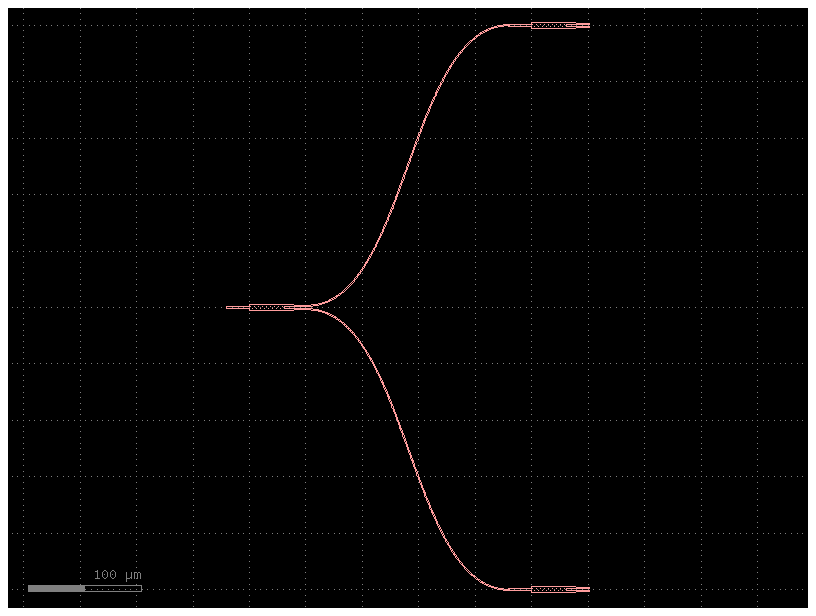

In [21]:
# Let's create a MMI tree


c = gf.Component()
c_mmi = cells.mmi1x2()

pad_x = 250
pad_y = 250

mmi1 = c.add_ref(c_mmi)
mmi2 = c.add_ref(c_mmi)
mmi3 = c.add_ref(c_mmi)

mmi2.dmovex(pad_x).dmovey(pad_y)
mmi3.dmovex(pad_x).dmovey(-pad_y)

gf.routing.route_single_sbend(component=c, port1=mmi1['o2'], port2=mmi2['o1'], cross_section='strip')
gf.routing.route_single_sbend(component=c, port1=mmi1['o3'], port2=mmi3['o1'], cross_section='strip')

c.plot()

In [22]:
# Once we "test" the high-level component, we can create a cell for it
@gf.cell 
def mmi_tree_1x4(pad_x = 250 ,pad_y = 250):
    c = gf.Component()
    c_mmi = cells.mmi1x2()
    mmi1 = c.add_ref(c_mmi)
    mmi2 = c.add_ref(c_mmi)
    mmi3 = c.add_ref(c_mmi)

    mmi2.dmovex(pad_x).dmovey(pad_y)
    mmi3.dmovex(pad_x).dmovey(-pad_y)

    gf.routing.route_single_sbend(component=c, port1= mmi1['o2'], port2=mmi2['o1'],cross_section='strip')
    gf.routing.route_single_sbend(component=c, port1= mmi1['o3'], port2=mmi3['o1'],cross_section='strip')
    c.add_port(name='o1', port=mmi1['o1'])
    c.add_port(name='o2', port=mmi2['o2'])
    c.add_port(name='o3', port=mmi2['o3'])
    c.add_port(name='o4', port=mmi3['o2'])
    c.add_port(name='o5', port=mmi3['o3'])
    c.draw_ports()
    return c

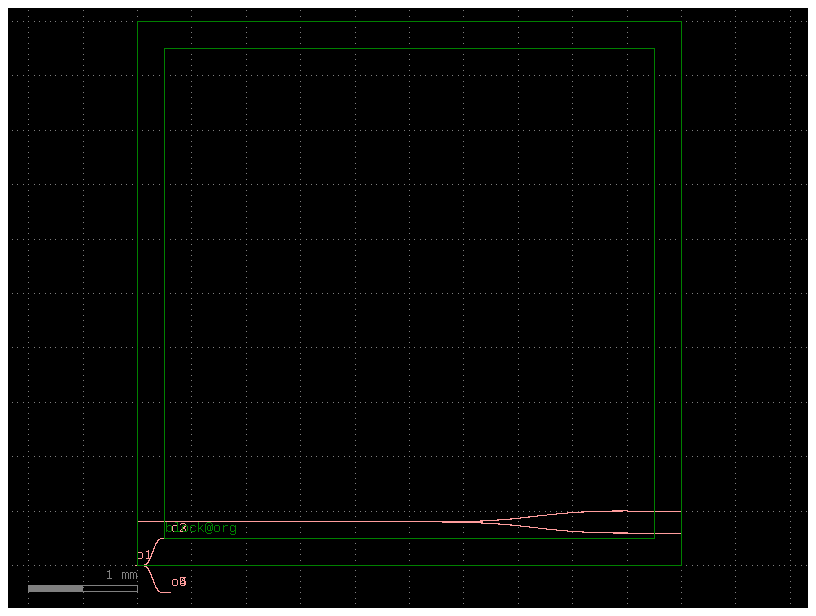

In [23]:
# With the cell created, we can instantiate and use it in our main component

cell_1x4 = main.add_ref(mmi_tree_1x4())
main.plot()


2026-06-02 23:56:31.502 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


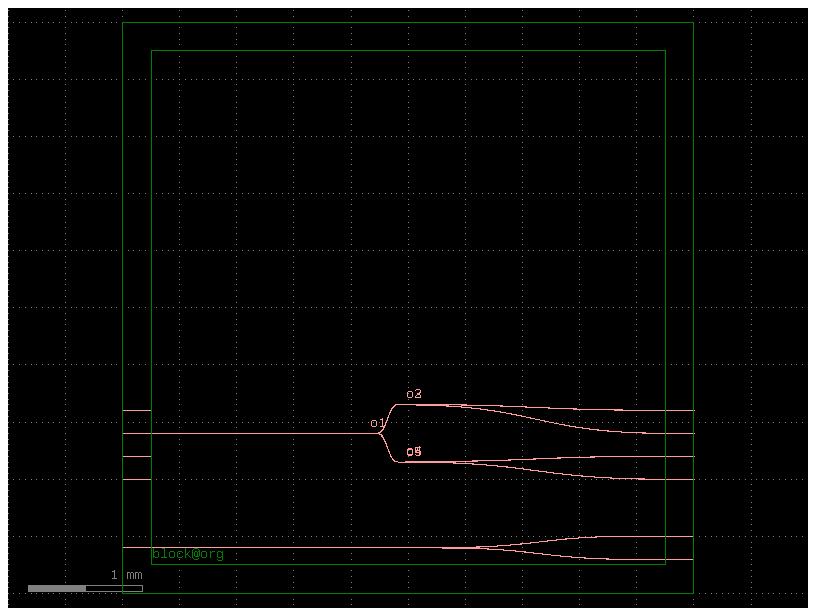

In [24]:
## Arrayed waveguides and MMI tree

sp = 200
border = 250

in_arr = main.add_ref(
    gf.components.straight_array(n=4, spacing=sp, length=border, cross_section=xs)
).dmovey(
    1000
)  #!!!!!! Easy to put IO Waveguides for a complete design !!!!

out_arr = (
    main.add_ref(
        gf.components.straight_array(n=4, spacing=sp, length=border, cross_section=xs)
    )
    .dmovex(dieW - border)
    .dmovey(1000)
)

cell_1x4.dmovex(0.5*dieW - mmi_tree_1x4().dxsize).dmovey(in_arr['o6'].dy)
gf.routing.route_single_sbend(component=main, port1=in_arr['o6'], port2=cell_1x4['o1'])
gf.routing.route_single_sbend(component=main, port1=cell_1x4['o2'], port2=out_arr['o4'])
gf.routing.route_single_sbend(component=main, port1=cell_1x4['o3'], port2=out_arr['o3'])
gf.routing.route_single_sbend(component=main, port1=cell_1x4['o4'], port2=out_arr['o2'])
gf.routing.route_single_sbend(component=main, port1=cell_1x4['o5'], port2=out_arr['o1'])
main.plot()
main.show()

### Mantra:
It's useful to use memorize this mantra: 
- Add_references 
- Connect_them
- Move_them

### Other Routing options examples:

Please check the GDSFactory Routing API for more information about advanced routing functionalities

[Routing API](https://gdsfactory.github.io/gdsfactory/api_routing.html) 

## 4. Exercise. 

- Now, add another MMI Tree, but in this case, with three levels. 
- You **must** define a PCell to define this structure
- Add two instances of your new parametric cell varying any parameter such as the pad on x or y, etc
- Connect the MMIs with output waveguides at the right side of the die. 

2026-06-02 23:56:32.215 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


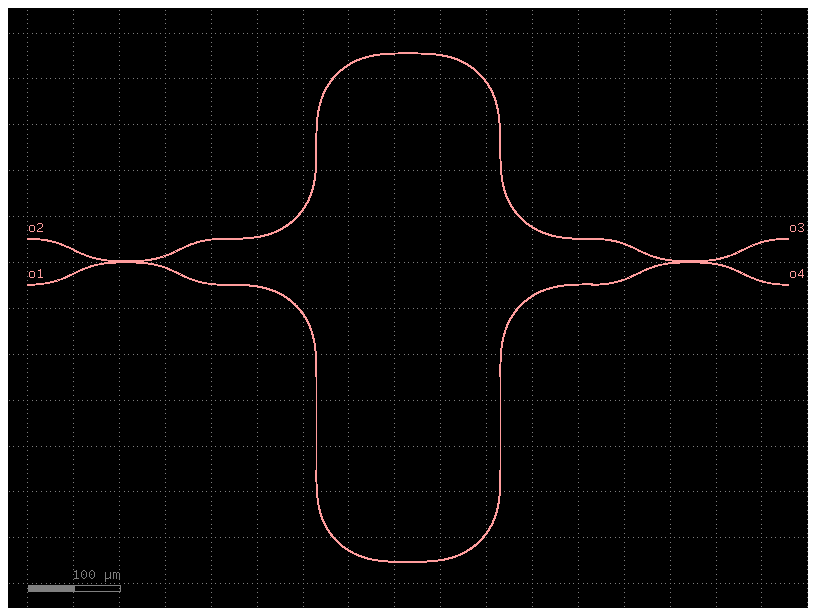

In [25]:


# 1. Unbalanced MZI
@gf.cell
def mzi_unbalanced(delta_length=200):
    c = gf.Component()
    mzi = c.add_ref(cells.mzi(delta_length=delta_length))
    c.add_port(name='o1', port=mzi['o1'])
    c.add_port(name='o2', port=mzi['o2'])
    c.add_port(name='o3', port=mzi['o3'])
    c.add_port(name='o4', port=mzi['o4'])
    c.draw_ports()
    return c

mzi_unbalanced().plot()
mzi_unbalanced().show()



2026-06-02 23:56:33.014 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


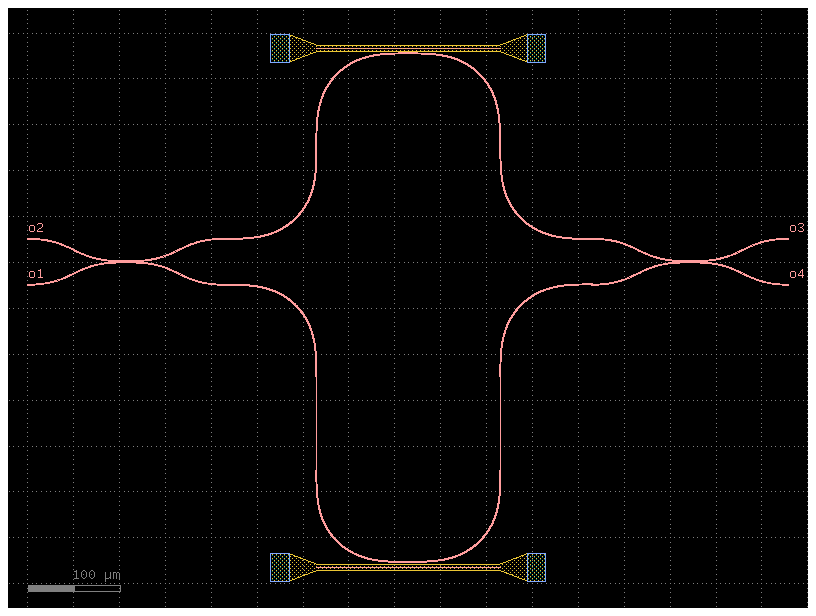

In [26]:
#Mzi with heater


@gf.cell
def mzi_heater(delta_length=200):
    c = gf.Component()
    mzi = c.add_ref(cells.mzi(delta_length=delta_length))
    heater = c.add_ref(cells.straight_heater_metal(length=delta_length))
    Hlength = heater.dxmax - heater.dxmin
    MZIlength = mzi.dxmax - mzi.dxmin
    dxCenter = float(MZIlength / 2) - (Hlength / 2)
    heater.move((dxCenter-50, mzi.dymax + 5))  
#manually centered to be constant with different delta length values
    heater2 = c.add_ref(cells.straight_heater_metal(length=delta_length))
    heater2.move((dxCenter-50, mzi.dymin - 5)) 
    c.add_port(name='o1', port=mzi['o1'])
    c.add_port(name='o2', port=mzi['o2'])
    c.add_port(name='o3', port=mzi['o3'])
    c.add_port(name='o4', port=mzi['o4'])
    c.draw_ports()
    return c

mzi_heater().plot()
mzi_heater().show()

2026-06-02 23:56:33.745 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


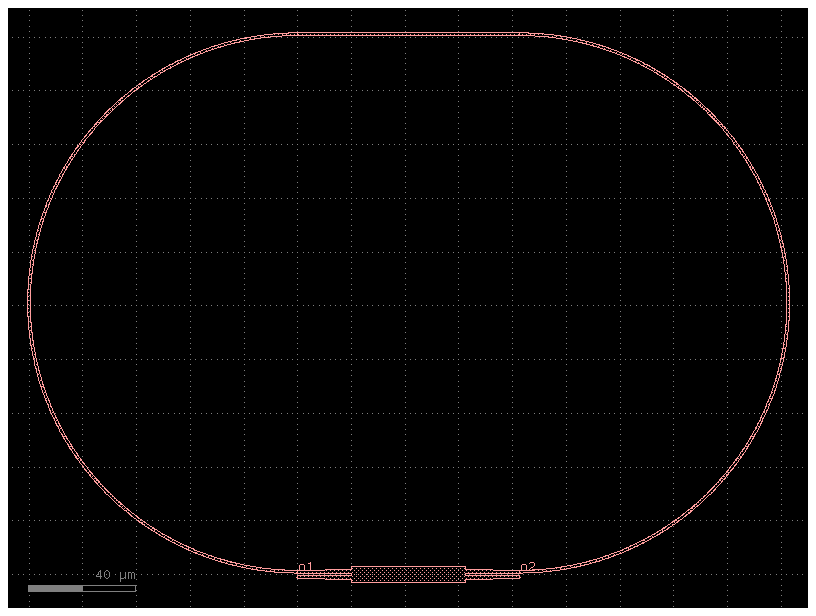

In [27]:
gf.clear_cache()

@gf.cell
def ring_ap(radius=100, gap_mmi=0.6):
    c = gf.Component()
    mmi = c.add_ref(cells.mmi2x2(gap_mmi=gap_mmi))
    
    xs_ring = gf.cross_section.strip(width=1.0, layer='WG', radius=radius, radius_min=0)
    
    gf.routing.route_dubins(
        component=c,
        port1=mmi['o3'],
        port2=mmi['o2'],
        cross_section=xs_ring,
    )
    
    c.add_port(name='o1', port=mmi['o1'])
    c.add_port(name='o2', port=mmi['o4'])
    c.draw_ports()
    return c

ring_ap().plot()
ring_ap().show()

2026-06-02 23:56:34.473 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


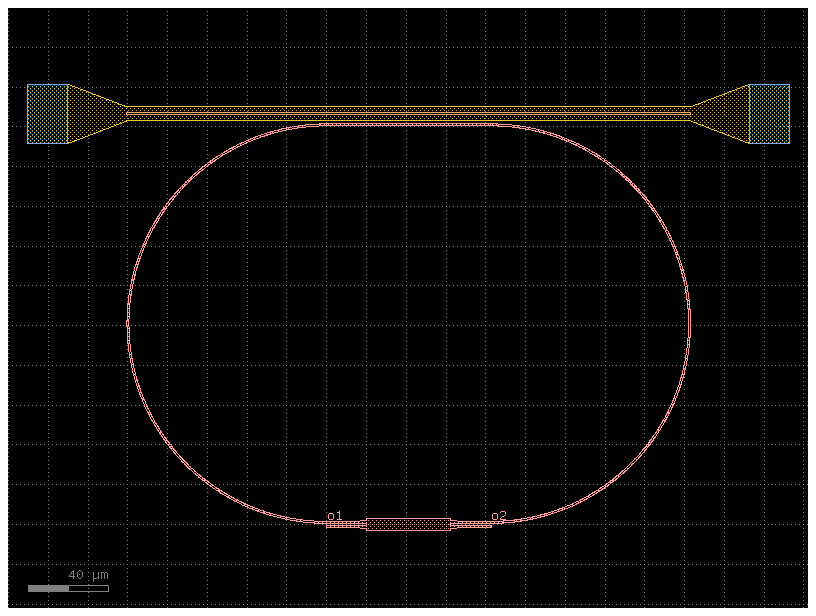

In [28]:


@gf.cell
def ring_heater(gap=0.6, radius=100):
    c = gf.Component()
    ring = c.add_ref(ring_ap(radius=radius,gap_mmi=gap))
    heater_length = ring.dxmax - ring.dxmin
    heater = c.add_ref(cells.straight_heater_metal(length=heater_length))
    heater.dmovex(ring.dxmin).dmovey((ring.dymax)+5) 
    c.add_port(name='o1', port=ring['o1'])
    c.add_port(name='o2', port=ring['o2'])
    c.draw_ports()
    return c

ring_heater().plot()
ring_heater().show()

2026-06-02 23:56:35.391 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


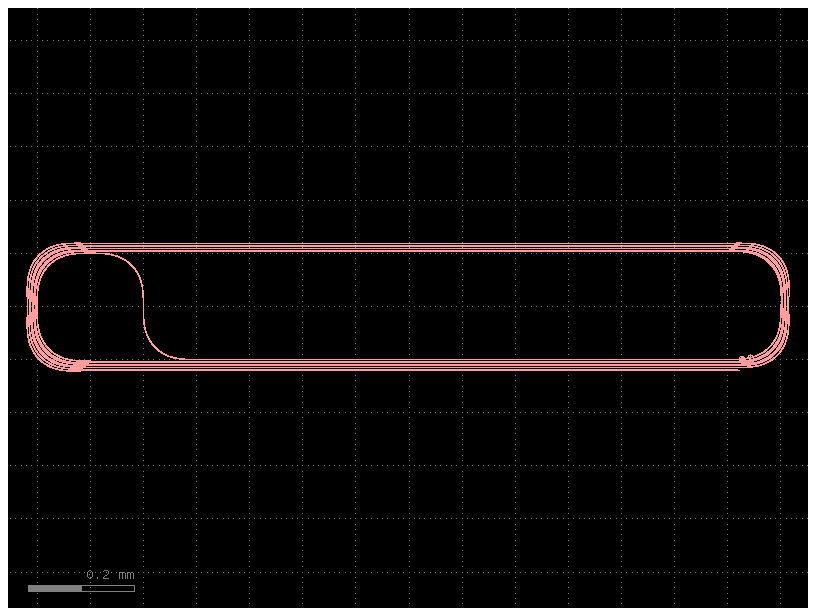

In [29]:
# 5. Spiral waveguide
@gf.cell
def spiral_wg(length=1000):
    c = gf.Component()
    s = c.add_ref(cells.spiral(length=length))
    c.add_port(name='o1', port=s['o1'])
    c.add_port(name='o2', port=s['o2'])
    c.draw_ports()
    return c

spiral_wg().plot()
spiral_wg().show()

2026-06-02 23:56:54.256 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


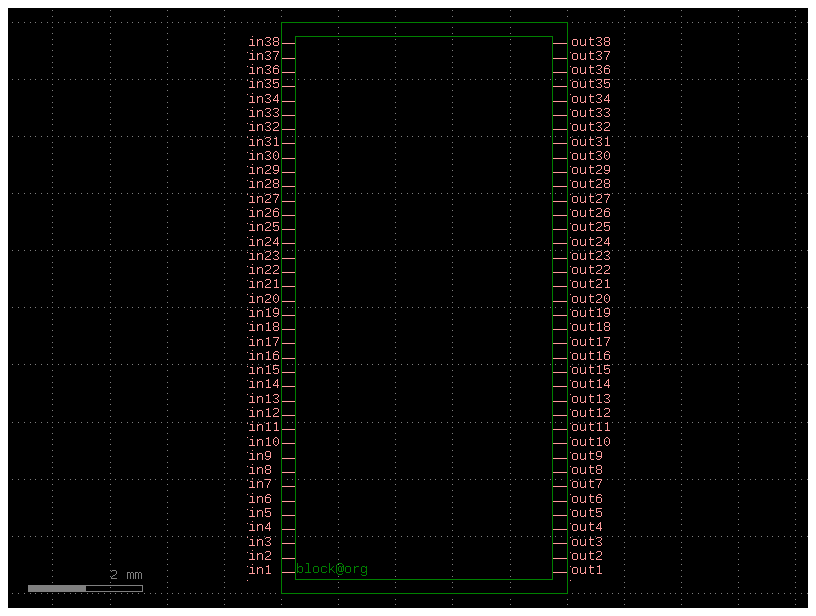

In [ ]:
gf.clear_cache()

@gf.cell
def die_with_ios(dieW=5000, dieL=10000, border=250, io_spacing=250):
    c = gf.Component()
    die_ref = c.add_ref(die(dieW=dieW, dieL=dieL, border=border))

    n_ios = int((dieL - 2 * border) / io_spacing)

    for i in range(n_ios):
        y = border + i * io_spacing + 125

        wg_left = c.add_ref(gf.components.straight(length=border, cross_section='strip'))
        wg_left.dmovex(0).dmovey(y)
        c.add_port(name=f'in{i+1}', port=wg_left['o2'])    # had to move the port names by hand so they do not overlap with the chip
        c.add_label(text=f'in{i+1}', position=(-600, y-150), layer='WG')

        wg_right = c.add_ref(gf.components.straight(length=border, cross_section='strip'))
        wg_right.dmovex(dieW - border).dmovey(y)
        c.add_port(name=f'out{i+1}', port=wg_right['o1'])
        c.add_label(text=f'out{i+1}', position=(dieW + 50, y-150), layer='WG')
        
    return c

die_with_ios().plot()
die_with_ios().show()

In [34]:
d = die_with_ios()
d.pprint_ports()

┏━━━━━━━┳━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┓
┃ name  ┃ width ┃ orientation ┃ layer    ┃ center           ┃ port_type ┃
┡━━━━━━━╇━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━┩
│ in1   │ 1.0   │ 0.0         │ WG (1/0) │ (250.0, 375.0)   │ optical   │
│ out1  │ 1.0   │ 180.0       │ WG (1/0) │ (4750.0, 375.0)  │ optical   │
│ in2   │ 1.0   │ 0.0         │ WG (1/0) │ (250.0, 625.0)   │ optical   │
│ out2  │ 1.0   │ 180.0       │ WG (1/0) │ (4750.0, 625.0)  │ optical   │
│ in3   │ 1.0   │ 0.0         │ WG (1/0) │ (250.0, 875.0)   │ optical   │
│ out3  │ 1.0   │ 180.0       │ WG (1/0) │ (4750.0, 875.0)  │ optical   │
│ in4   │ 1.0   │ 0.0         │ WG (1/0) │ (250.0, 1125.0)  │ optical   │
│ out4  │ 1.0   │ 180.0       │ WG (1/0) │ (4750.0, 1125.0) │ optical   │
│ in5   │ 1.0   │ 0.0         │ WG (1/0) │ (250.0, 1375.0)  │ optical   │
│ out5  │ 1.0   │ 180.0       │ WG (1/0) │ (4750.0, 1375.0) │ optical   │
│ in6   │ 1.0   │ 0.0         │ WG (1/0) │ (250.0, 1625.0)  │ optical   │
│ out6  │ 1.0   │ 180.0       │ WG (1/0) │ (4750.0, 1625.0) │ optical   │
│ in7   │ 1.0   │ 0.0         │ WG (1/0) │ (250.0, 1875.0)  │ optical   │
│ out7  │ 1.0   │ 180.0       │ WG (1/0) │ (4750.0, 1875.0) │ optical   │
│ in8   │ 1.0   │ 0.0         │ WG (1/0) │ (250.0, 2125.0)  │ optical   │
│ out8  │ 1.0   │ 180.0       │ WG (1/0) │ (4750.0, 2125.0) │ optical   │
│ in9   │ 1.0   │ 0.0         │ WG (1/0) │ (250.0, 2375.0)  │ optical   │
│ out9  │ 1.0   │ 180.0       │ WG (1/0) │ (4750.0, 2375.0) │ optical   │
│ in10  │ 1.0   │ 0.0         │ WG (1/0) │ (250.0, 2625.0)  │ optical   │
│ out10 │ 1.0   │ 180.0       │ WG (1/0) │ (4750.0, 2625.0) │ optical   │
│ in11  │ 1.0   │ 0.0         │ WG (1/0) │ (250.0, 2875.0)  │ optical   │
│ out11 │ 1.0   │ 180.0       │ WG (1/0) │ (4750.0, 2875.0) │ optical   │
│ in12  │ 1.0   │ 0.0         │ WG (1/0) │ (250.0, 3125.0)  │ optical   │
│ out12 │ 1.0   │ 180.0       │ WG (1/0) │ (4750.0, 3125.0) │ optical   │
│ in13  │ 1.0   │ 0.0         │ WG (1/0) │ (250.0, 3375.0)  │ optical   │
│ out13 │ 1.0   │ 180.0       │ WG (1/0) │ (4750.0, 3375.0) │ optical   │
│ in14  │ 1.0   │ 0.0         │ WG (1/0) │ (250.0, 3625.0)  │ optical   │
│ out14 │ 1.0   │ 180.0       │ WG (1/0) │ (4750.0, 3625.0) │ optical   │
│ in15  │ 1.0   │ 0.0         │ WG (1/0) │ (250.0, 3875.0)  │ optical   │
│ out15 │ 1.0   │ 180.0       │ WG (1/0) │ (4750.0, 3875.0) │ optical   │
│ in16  │ 1.0   │ 0.0         │ WG (1/0) │ (250.0, 4125.0)  │ optical   │
│ out16 │ 1.0   │ 180.0       │ WG (1/0) │ (4750.0, 4125.0) │ optical   │
│ in17  │ 1.0   │ 0.0         │ WG (1/0) │ (250.0, 4375.0)  │ optical   │
│ out17 │ 1.0   │ 180.0       │ WG (1/0) │ (4750.0, 4375.0) │ optical   │
│ in18  │ 1.0   │ 0.0         │ WG (1/0) │ (250.0, 4625.0)  │ optical   │
│ out18 │ 1.0   │ 180.0       │ WG (1/0) │ (4750.0, 4625.0) │ optical   │
│ in19  │ 1.0   │ 0.0         │ WG (1/0) │ (250.0, 4875.0)  │ optical   │
│ out19 │ 1.0   │ 180.0       │ WG (1/0) │ (4750.0, 4875.0) │ optical   │
│ in20  │ 1.0   │ 0.0         │ WG (1/0) │ (250.0, 5125.0)  │ optical   │
│ out20 │ 1.0   │ 180.0       │ WG (1/0) │ (4750.0, 5125.0) │ optical   │
│ in21  │ 1.0   │ 0.0         │ WG (1/0) │ (250.0, 5375.0)  │ optical   │
│ out21 │ 1.0   │ 180.0       │ WG (1/0) │ (4750.0, 5375.0) │ optical   │
│ in22  │ 1.0   │ 0.0         │ WG (1/0) │ (250.0, 5625.0)  │ optical   │
│ out22 │ 1.0   │ 180.0       │ WG (1/0) │ (4750.0, 5625.0) │ optical   │
│ in23  │ 1.0   │ 0.0         │ WG (1/0) │ (250.0, 5875.0)  │ optical   │
│ out23 │ 1.0   │ 180.0       │ WG (1/0) │ (4750.0, 5875.0) │ optical   │
│ in24  │ 1.0   │ 0.0         │ WG (1/0) │ (250.0, 6125.0)  │ optical   │
│ out24 │ 1.0   │ 180.0       │ WG (1/0) │ (4750.0, 6125.0) │ optical   │
│ in25  │ 1.0   │ 0.0         │ WG (1/0) │ (250.0, 6375.0)  │ optical   │
│ out25 │ 1.0   │ 180.0       │ WG (1/0) │ (4750.0, 6375.0) │ optical   │
│ in26  │ 1.0   │ 0.0         │ WG (1/0) │ (250.0, 6625.0)  │ optical   │
│ ou

2026-06-03 00:04:40.532 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


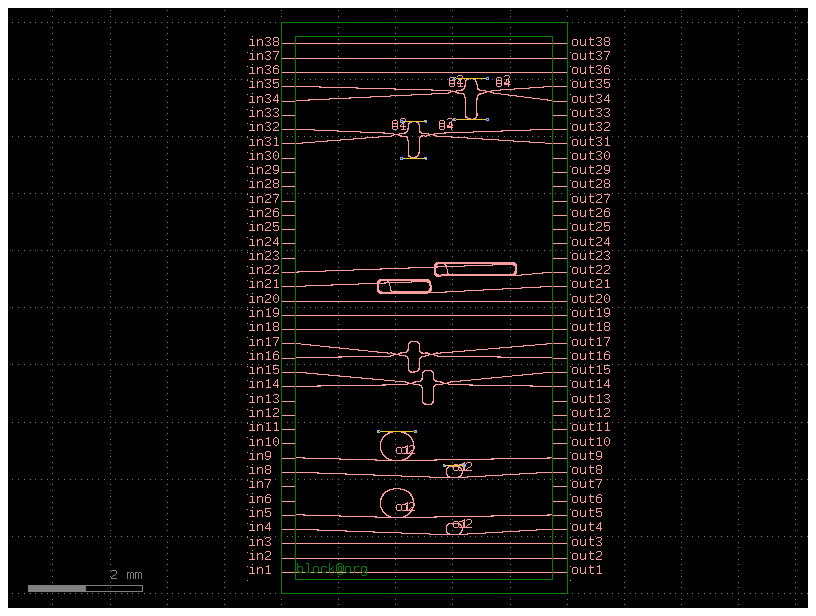

In [37]:
gf.clear_cache()

main = gf.Component()
host = main.add_ref(die_with_ios())
xs = 'strip'
# 3 sets of 3 straight waveguides: top, middle, bottom aligned to I/O ports
for y_pos in [375, 9125, 4625]:
    for offset in [0, 250, 500]:
        main.add_ref(
            gf.components.straight(length=4500, cross_section=xs)
        ).dmovex(250).dmovey(y_pos + offset)

mzi_a = main.add_ref(cells.mzi(delta_length=286))
mzi_b = main.add_ref(cells.mzi(delta_length=150))
mzi_a.dmovex(2250).dmovey(host['in14'].dy - mzi_a['o1'].dy + mzi_a.dy+100)
mzi_b.dmovex(2000).dmovey(host['in16'].dy - mzi_a['o1'].dy + mzi_a.dy+100)
gf.routing.route_dubins(component=main, port1=host['in14'], port2=mzi_a['o1'], cross_section=xs)
gf.routing.route_dubins(component=main, port1=host['in15'], port2=mzi_a['o2'], cross_section=xs)
gf.routing.route_dubins(component=main, port1=host['out14'], port2=mzi_a['o4'], cross_section=xs)
gf.routing.route_dubins(component=main, port1=host['out15'], port2=mzi_a['o3'], cross_section=xs)
gf.routing.route_dubins(component=main, port1=host['in16'], port2=mzi_b['o1'], cross_section=xs)
gf.routing.route_dubins(component=main, port1=host['in17'], port2=mzi_b['o2'], cross_section=xs)
gf.routing.route_dubins(component=main, port1=host['out16'], port2=mzi_b['o4'], cross_section=xs)
gf.routing.route_dubins(component=main, port1=host['out17'], port2=mzi_b['o3'], cross_section=xs)

ring_a = main.add_ref(ring_ap(radius=100,gap_mmi=0.6))
ring_b = main.add_ref(ring_ap(radius=250,gap_mmi=0.6))
ring_a.dmovex(3000).dmovey(host['in4'].dy - mzi_a['o1'].dy + mzi_a.dy-50)
ring_b.dmovex(2000).dmovey(host['in5'].dy - mzi_a['o1'].dy + mzi_a.dy)
gf.routing.route_dubins(component=main, port1=host['in4'], port2=ring_a['o1'], cross_section=xs)
gf.routing.route_dubins(component=main, port1=host['out4'], port2=ring_a['o2'], cross_section=xs)
gf.routing.route_dubins(component=main, port1=host['in5'], port2=ring_b['o1'], cross_section=xs)
gf.routing.route_dubins(component=main, port1=host['out5'], port2=ring_b['o2'], cross_section=xs)

ring_h1 = main.add_ref(ring_heater(radius=100))
ring_h2 = main.add_ref(ring_heater(radius=250))
ring_h1.dmovex(3000).dmovey(host['in8'].dy - mzi_a['o1'].dy + mzi_a.dy-50)
ring_h2.dmovex(2000).dmovey(host['in9'].dy - mzi_a['o1'].dy + mzi_a.dy)
gf.routing.route_dubins(component=main, port1=host['in8'], port2=ring_h1['o1'], cross_section=xs)
gf.routing.route_dubins(component=main, port1=host['out8'], port2=ring_h1['o2'], cross_section=xs)
gf.routing.route_dubins(component=main, port1=host['in9'], port2=ring_h2['o1'], cross_section=xs)
gf.routing.route_dubins(component=main, port1=host['out9'], port2=ring_h2['o2'], cross_section=xs)

spiral_a = main.add_ref(cells.spiral(length=1000))
spiral_b = main.add_ref(cells.spiral(length=500))
spiral_a.dmovex(3000).dmovey(host['in22'].dy - mzi_a['o1'].dy + mzi_a.dy)
spiral_b.dmovex(2000).dmovey(host['in21'].dy - mzi_a['o1'].dy + mzi_a.dy-50)
gf.routing.route_dubins(component=main, port1=host['in22'], port2=spiral_a['o1'], cross_section=xs)
gf.routing.route_dubins(component=main, port1=host['out22'], port2=spiral_a['o2'], cross_section=xs)
gf.routing.route_dubins(component=main, port1=host['in21'], port2=spiral_b['o1'], cross_section=xs)
gf.routing.route_dubins(component=main, port1=host['out21'], port2=spiral_b['o2'], cross_section=xs)

mzi_h1 = main.add_ref(mzi_heater(delta_length=500))
mzi_h2 = main.add_ref(mzi_heater(delta_length=350))
mzi_h1.dmovex(3000).dmovey(host['in35'].dy - mzi_a['o1'].dy + mzi_a.dy-50)
mzi_h2.dmovex(2000).dmovey(host['in32'].dy - mzi_a['o1'].dy + mzi_a.dy-50)
gf.routing.route_dubins(component=main, port1=host['in34'], port2=mzi_h1['o1'], cross_section=xs)
gf.routing.route_dubins(component=main, port1=host['in35'], port2=mzi_h1['o2'], cross_section=xs)
gf.routing.route_dubins(component=main, port1=host['out35'], port2=mzi_h1['o3'], cross_section=xs)
gf.routing.route_dubins(component=main, port1=host['out34'], port2=mzi_h1['o4'], cross_section=xs)
gf.routing.route_dubins(component=main, port1=host['in31'], port2=mzi_h2['o1'], cross_section=xs)
gf.routing.route_dubins(component=main, port1=host['in32'], port2=mzi_h2['o2'], cross_section=xs)
gf.routing.route_dubins(component=main, port1=host['out32'], port2=mzi_h2['o3'], cross_section=xs)
gf.routing.route_dubins(component=main, port1=host['out31'], port2=mzi_h2['o4'], cross_section=xs)

main.plot()
main.show()